In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
url = "https://raw.githubusercontent.com/Sahdam/Yield-Curve-Analysis-FGN-BOND-/main/Government_Securities_in_Excel%20(1).csv"
df = pd.read_csv(url, encoding='latin1')

In [3]:
df.head()

,auctionDate,securityType,tenor,auctionNo,auction,week,maturityDate,totalSubscription,totalSuccessful,rangeBid,successfulBidRates,rateDescription,rate,trueYield,amtOffered,totalAmtRepaid,netType,netValue
0,04/03/2026,NTB,91DAY,04-03-2026 91DAY,Primary Market,1st Week,04/06/2026,80923.856,64269.8540,14.8000 - 18.0000,14.800 - 15.9500,Issue,15.95,0.0000,100000.0000,0.0000,Sales,64269.8540
1,04/03/2026,NTB,182DAY,04-03-2026 182DAY,Primary Market,1st Week,03/09/2026,136539.824,91434.5230,15.0000 -18.8000,15.0000 - 16.6500,Issue,16.65,0.0000,150000.0000,0.0000,Sales,91434.5230
2,04/03/2026,NTB,364DAY,04-03-2026 364DAY,Primary Market,1st Week,04/03/2027,2126819.307,856034.5120,15.0000 - 22.0000,15.0000 - 16.7300,Issue,16.73,0.0000,80000.0000,0.0000,Sales,856034.5120
3,03/03/2026,OMO,7DAY,03-03-2026 7DAY,OMO,1st Week,10/03/2026,56000.000,0.0000,22.5000 - 23.0000,0.0000,Issue,0.00,0.0000,200000.0000,0.0000,Sales,0.0000
4,03/03/2026,OMO,98DAY,03-03-2026 98DAY,OMO,1st Week,09/06/2026,104250.000,62000.0000,19.3400 - 20.7700,19.3400 - 19.3500,Issue,19.35,0.0000,200000.0000,0.0000,Sales,62000.0000


In [4]:
df["tenor"].unique()

array(['91DAY', '182DAY', '364DAY', '7DAY', '98DAY', '105DAY', '207DAY',
       '354DAY', '208DAY', '348DAY', '203DAY', '161DAY', '210DAY',
       '168DAY', '162DAY', '211DAY', '180DAY', '215DAY', '174DAY',
       '188DAY', '175DAY', '152DAY', '173DAY', '56DAY', '81DAY', '91 DAY',
       '196DAY', '252DAY', '193DAY', '249DAY', '109DAY', '151DAY',
       '85DAY', '99DAY', '120DAY', '88DAY', '102DAY', '123DAY', '84DAY',
       '245DAY', '204DAY', '363DAY', '260DAY', '155DAY', '106DAY',
       '232DAY', '104DAY', '139DAY', '169DAY', '315DAY', '329DAY',
       '350DAY', '298DAY', '319DAY', '355DAY', '362DAY', '183 DAY',
       '347DAY', '361DAY', '358DAY', '365DAY', '90 DAY', '181 DAY',
       '363 DAY', '182 DAY', '364 DAY', '351DAY', '186DAY', '95DAY',
       '179DAY', '89 DAY', '187 DAY', '362 DAY', '193 DAY', '361 DAY',
       '96 DAY', '194 DAY', '365 DAY', '85 DAYS', '92DAY', '176DAY',
       '81 Day', '179 Day', '347 Day', '109 DAY', '186 DAY', '354 DAY',
       '188 DAY', '105 DAYS

In [5]:
df['securityType'].unique()

array(['NTB', 'OMO', 'OMOM', 'FGN BOND', 'FGN BONDS', 'FGN Bonds',
       'FGB BONDS', 'FGN BODS', 'OMO ', 'omo', 'FGN Bond', 'NT Bonds',
       'Others', 'Bonds', 'Nigerian Saving Certificate',
       'CBN Certificate'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4634 entries, 0 to 4633
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   auctionDate         4634 non-null   object 
 1   securityType        4634 non-null   object 
 2   tenor               4634 non-null   object 
 3   auctionNo           4634 non-null   object 
 4   auction             4634 non-null   object 
 5   week                4634 non-null   object 
 6   maturityDate        4634 non-null   object 
 7   totalSubscription   4634 non-null   float64
 8   totalSuccessful     4634 non-null   object 
 9   rangeBid            4634 non-null   object 
 10  successfulBidRates  4634 non-null   object 
 11  rateDescription     4634 non-null   object 
 12  rate                4634 non-null   float64
 13  trueYield           4634 non-null   object 
 14  amtOffered          4634 non-null   object 
 15  totalAmtRepaid      4634 non-null   object 
 16  netTyp

In [7]:
df.isnull().sum()

,0
auctionDate,0
securityType,0
tenor,0
auctionNo,0
auction,0
week,0
maturityDate,0
totalSubscription,0
totalSuccessful,0
rangeBid,0


In [8]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (4634, 18)

Columns: ['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week', 'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid', 'successfulBidRates', 'rateDescription', 'rate', 'trueYield', 'amtOffered', 'totalAmtRepaid', 'netType', 'netValue']

First 3 rows:
   auctionDate securityType   tenor          auctionNo         auction  \
0  04/03/2026          NTB   91DAY   04-03-2026 91DAY  Primary Market   
1  04/03/2026          NTB  182DAY  04-03-2026 182DAY  Primary Market   
2  04/03/2026          NTB  364DAY  04-03-2026 364DAY  Primary Market   

       week maturityDate  totalSubscription totalSuccessful  \
0  1st Week   04/06/2026          80923.856      64269.8540   
1  1st Week   03/09/2026         136539.824      91434.5230   
2  1st Week   04/03/2027        2126819.307     856034.5120   

            rangeBid successfulBidRates rateDescription   rate trueYield  \
0  14.8000 - 18.0000   14.800 - 15.9500           Issue  15.95    0.0000   


In [9]:
def clean_security_type(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().upper()
    if 'FGN' in s and ('BOND' in s or 'BOD' in s):
        return 'FGN BOND'
    elif s in ['NTB']:
        return 'NTB'
    elif 'OMO' in s:
        return 'OMO'
    elif 'NT BOND' in s or s == 'BONDS':
        return 'FGN BOND'
    else:
        return s


In [10]:
df['security_type_clean'] = df['securityType'].apply(clean_security_type)

print(df['security_type_clean'].value_counts())

security_type_clean
NTB                            2573
OMO                            1532
FGN BOND                        508
CBN CERTIFICATE                  10
OTHERS                            7
NIGERIAN SAVING CERTIFICATE       3
FGB BONDS                         1
Name: count, dtype: int64


In [11]:
df['auction_date'] = pd.to_datetime(df['auctionDate'], dayfirst=True, errors='coerce')
df['maturity_date'] = pd.to_datetime(df['maturityDate'], dayfirst=True, errors='coerce')

df['tenor_days'] = (df['maturity_date'] - df['auction_date']).dt.days

print("\nTenor range:")
print(df['tenor_days'].describe())
print("\nNegative or zero tenors:", (df['tenor_days'] <= 0).sum())


Tenor range:
count     4634.000000
mean       559.311610
std       1763.952839
min       -309.000000
25%         92.000000
50%        182.000000
75%        355.000000
max      66475.000000
Name: tenor_days, dtype: float64

Negative or zero tenors: 21


In [12]:
def classify_tenor(days):
    if pd.isna(days) or days <= 0:
        return np.nan
    elif days <= 100:
        return '91D'
    elif days <= 200:
        return '182D'
    elif days <= 400:
        return '364D'
    elif days <= 600:
        return '2Y'
    elif days <= 1200:
        return '3Y'
    elif days <= 2000:
        return '5Y'
    elif days <= 2800:
        return '7Y'
    elif days <= 4000:
        return '10Y'
    elif days <= 6000:
        return '15Y'
    elif days <= 8000:
        return '20Y'
    elif days <= 11000:
        return '25Y'
    else:
        return '30Y'

In [13]:
df['tenor_bucket'] = df['tenor_days'].apply(classify_tenor)
print("\nTenor bucket counts:")
print(df['tenor_bucket'].value_counts().sort_index())


Tenor bucket counts:
tenor_bucket
10Y      104
15Y       24
182D    1518
20Y       70
25Y       40
2Y         4
30Y        2
364D    1086
3Y        73
5Y       115
7Y        46
91D     1531
Name: count, dtype: int64


In [14]:
df_clean = df[df['security_type_clean'].isin(['NTB', 'FGN BOND'])].copy()

In [15]:
standard_tenors = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y',
                   '15Y', '20Y', '25Y', '30Y']
df_clean = df_clean[df_clean['tenor_bucket'].isin(standard_tenors)]

In [16]:
print("\nCleaned dataset shape:", df_clean.shape)
print("\nDate range:", df_clean['auction_date'].min(),
      "to", df_clean['auction_date'].max())


Cleaned dataset shape: (3067, 23)

Date range: 2001-04-17 00:00:00 to 2026-03-04 00:00:00


In [17]:
df_clean.head(10)

,auctionDate,securityType,tenor,auctionNo,auction,week,maturityDate,totalSubscription,totalSuccessful,rangeBid,...,trueYield,amtOffered,totalAmtRepaid,netType,netValue,security_type_clean,auction_date,maturity_date,tenor_days,tenor_bucket
0,04/03/2026,NTB,91DAY,04-03-2026 91DAY,Primary Market,1st Week,04/06/2026,80923.856,64269.8540,14.8000 - 18.0000,...,0.0000,100000.0000,0.0000,Sales,64269.8540,NTB,2026-03-04,2026-06-04,92,91D
1,04/03/2026,NTB,182DAY,04-03-2026 182DAY,Primary Market,1st Week,03/09/2026,136539.824,91434.5230,15.0000 -18.8000,...,0.0000,150000.0000,0.0000,Sales,91434.5230,NTB,2026-03-04,2026-09-03,183,182D
2,04/03/2026,NTB,364DAY,04-03-2026 364DAY,Primary Market,1st Week,04/03/2027,2126819.307,856034.5120,15.0000 - 22.0000,...,0.0000,80000.0000,0.0000,Sales,856034.5120,NTB,2026-03-04,2027-03-04,365,364D
6,04/02/2026,NTB,91DAY,05-02-2026 91DAY,Primary Market,1st Week,07/05/2026,66050.846,63213.8460,14.5000 - 20.0000,...,0.0000,150000.0000,0.0000,Sales,63213.8460,NTB,2026-02-04,2026-05-07,92,91D
7,04/02/2026,NTB,182DAY,05-02-2026 182DAY,Primary Market,1st Week,06/08/2026,123407.708,80609.7070,15.6000 - 20.0300,...,0.0000,200000.0000,0.0000,Sales,80609.7070,NTB,2026-02-04,2026-08-06,183,182D
8,04/02/2026,NTB,364DAY,05-02-2026 364DAY,Primary Market,1st Week,04/02/2027,4396832.675,808784.1090,16.0000 - 21.0000,...,0.0000,800000.0000,0.0000,Sales,808784.1090,NTB,2026-02-04,2027-02-04,365,364D
15,07/01/2026,NTB,91DAY,07-01-2026 91DAY,Primary Market,2nd Week,09/04/2026,112263.000,108107.0000,15.0000 - 16.0000,...,0.0000,150000.0000,0.0000,Sales,108107.0000,NTB,2026-01-07,2026-04-09,92,91D
16,07/01/2026,NTB,182DAY,07-01-2026 182DAY,Primary Market,2nd Week,09/07/2026,49910.111,48230.1110,15.8500 - 17.2500,...,0.0000,200000.0000,0.0000,Sales,48230.1110,NTB,2026-01-07,2026-07-09,183,182D
17,07/01/2026,NTB,364DAY,07-01-2026 364DAY,Primary Market,2nd Week,07/01/2027,1380775.870,987784.8700,16.4200 - 21.0000,...,0.0000,800000.0000,0.0000,Sales,987784.8700,NTB,2026-01-07,2027-01-07,365,364D
24,17/12/2025,NTB,91DAY,17-12-2025 91DAY,Primary Market,3rd Week,19/03/2026,100626.463,100013.9630,14.8500 - 17.0000,...,0.0000,100000.0000,0.0000,Sales,100013.9630,NTB,2025-12-17,2026-03-19,92,91D


In [18]:
df.columns

Index(['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week',
       'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid',
       'successfulBidRates', 'rateDescription', 'rate', 'trueYield',
       'amtOffered', 'totalAmtRepaid', 'netType', 'netValue',
       'security_type_clean', 'auction_date', 'maturity_date', 'tenor_days',
       'tenor_bucket'],
      dtype='object')

In [19]:
print("\nAll columns:", df_clean.columns.tolist())

df_clean = df_clean.rename(columns={'rate': 'yield_pct'})

df_clean['yield_pct'] = pd.to_numeric(df_clean['yield_pct'], errors='coerce')


All columns: ['auctionDate', 'securityType', 'tenor', 'auctionNo', 'auction', 'week', 'maturityDate', 'totalSubscription', 'totalSuccessful', 'rangeBid', 'successfulBidRates', 'rateDescription', 'rate', 'trueYield', 'amtOffered', 'totalAmtRepaid', 'netType', 'netValue', 'security_type_clean', 'auction_date', 'maturity_date', 'tenor_days', 'tenor_bucket']


In [20]:
yield_curve = df_clean.pivot_table(
    index='auction_date',
    columns='tenor_bucket',
    values='yield_pct',
    aggfunc='mean'
)


In [21]:
col_order = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y',
             '10Y', '15Y', '20Y', '25Y', '30Y']
yield_curve = yield_curve.reindex(
    columns=[c for c in col_order if c in yield_curve.columns]
)

In [22]:
print("\nYield curve table (first 5 rows):")
print(yield_curve.head())
print("\nShape:", yield_curve.shape)


Yield curve table (first 5 rows):
tenor_bucket    91D   182D  364D  2Y    3Y  5Y  7Y  10Y  15Y  20Y  25Y  30Y
auction_date                                                               
2001-04-17      NaN    NaN   NaN NaN  21.5 NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-03      NaN  20.75   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-04    20.30    NaN   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-10      NaN  21.00   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN
2002-01-11    20.75    NaN   NaN NaN   NaN NaN NaN  NaN  NaN  NaN  NaN  NaN

Shape: (1482, 12)


In [23]:
yield_curve.head()

tenor_bucket,91D,182D,364D,2Y,3Y,5Y,7Y,10Y,15Y,20Y,25Y,30Y
auction_date,,,,,,,,,,,,
2001-04-17,NaN,NaN,NaN,NaN,21.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-03,NaN,20.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-04,20.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-10,NaN,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-11,20.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
yield_curve.std()

,0
tenor_bucket,
91D,5.176880
182D,5.318094
364D,4.743987
2Y,5.868986
3Y,2.468953
5Y,2.494010
7Y,2.331955
10Y,2.184866
15Y,3.099511


In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("=== Before cleaning ===")
print(yield_curve.describe())

yield_curve_clean = yield_curve.copy()
yield_curve_clean[yield_curve_clean < 1.0] = np.nan

print("\n=== After removing zeros ===")
print(yield_curve_clean.describe())


yield_curve_filled = yield_curve_clean.copy()
yield_curve_filled = yield_curve_filled.ffill(limit=7)


periods = {
    'Pre-Crisis (2001–2008)':      ('2001-01-01', '2008-12-31'),
    'Post-Crisis (2009–2015)':     ('2009-01-01', '2015-12-31'),
    'Recession Period (2016–2017)':('2016-01-01', '2017-12-31'),
    'Stability (2018–2021)':       ('2018-01-01', '2021-12-31'),
    'Hiking Cycle (2022–2024)':    ('2022-01-01', '2024-12-31'),
}


yield_curve_clean['slope_1Y_3M'] = (
    yield_curve_clean['364D'] - yield_curve_clean['91D']
)

yield_curve_clean['slope_10Y_3M'] = (
    yield_curve_clean['10Y'] - yield_curve_clean['91D']
)

print("\n=== Slope Statistics ===")
print(yield_curve_clean[['slope_1Y_3M', 'slope_10Y_3M']].describe())

# ── STEP 5: RESAMPLE TO MONTHLY (cleaner for visualisation) ───────────
yield_monthly = yield_curve_clean.resample('ME').mean()

print("\n=== Monthly dataset ===")
print(f"Shape: {yield_monthly.shape}")
print(f"Date range: {yield_monthly.index.min()} to {yield_monthly.index.max()}")
print(yield_monthly.head(10))

=== Before cleaning ===
tenor_bucket         91D        182D        364D         2Y         3Y  \
count         1072.00000  811.000000  523.000000   2.000000  73.000000   
mean             8.91078   10.042645   11.403890  18.850000  10.533871   
std              5.17688    5.318094    4.743987   5.868986   2.468953   
min              0.00000    0.000000    0.000000  14.700000   4.860000   
25%              4.80000    6.440000    8.985000  16.775000   9.200000   
50%              9.10000    9.450000   11.049000  18.850000  10.500000   
75%             13.50000   13.860000   14.225000  20.925000  12.000000   
max             22.25000   22.500000   23.500000  23.000000  21.500000   

tenor_bucket         5Y         7Y         10Y        15Y        20Y  \
count         114.00000  45.000000  101.000000  24.000000  69.000000   
mean           12.76322  13.009416   13.558882  11.573542  13.545145   
std             2.49401   2.331955    2.184866   3.099511   2.539762   
min             4.000

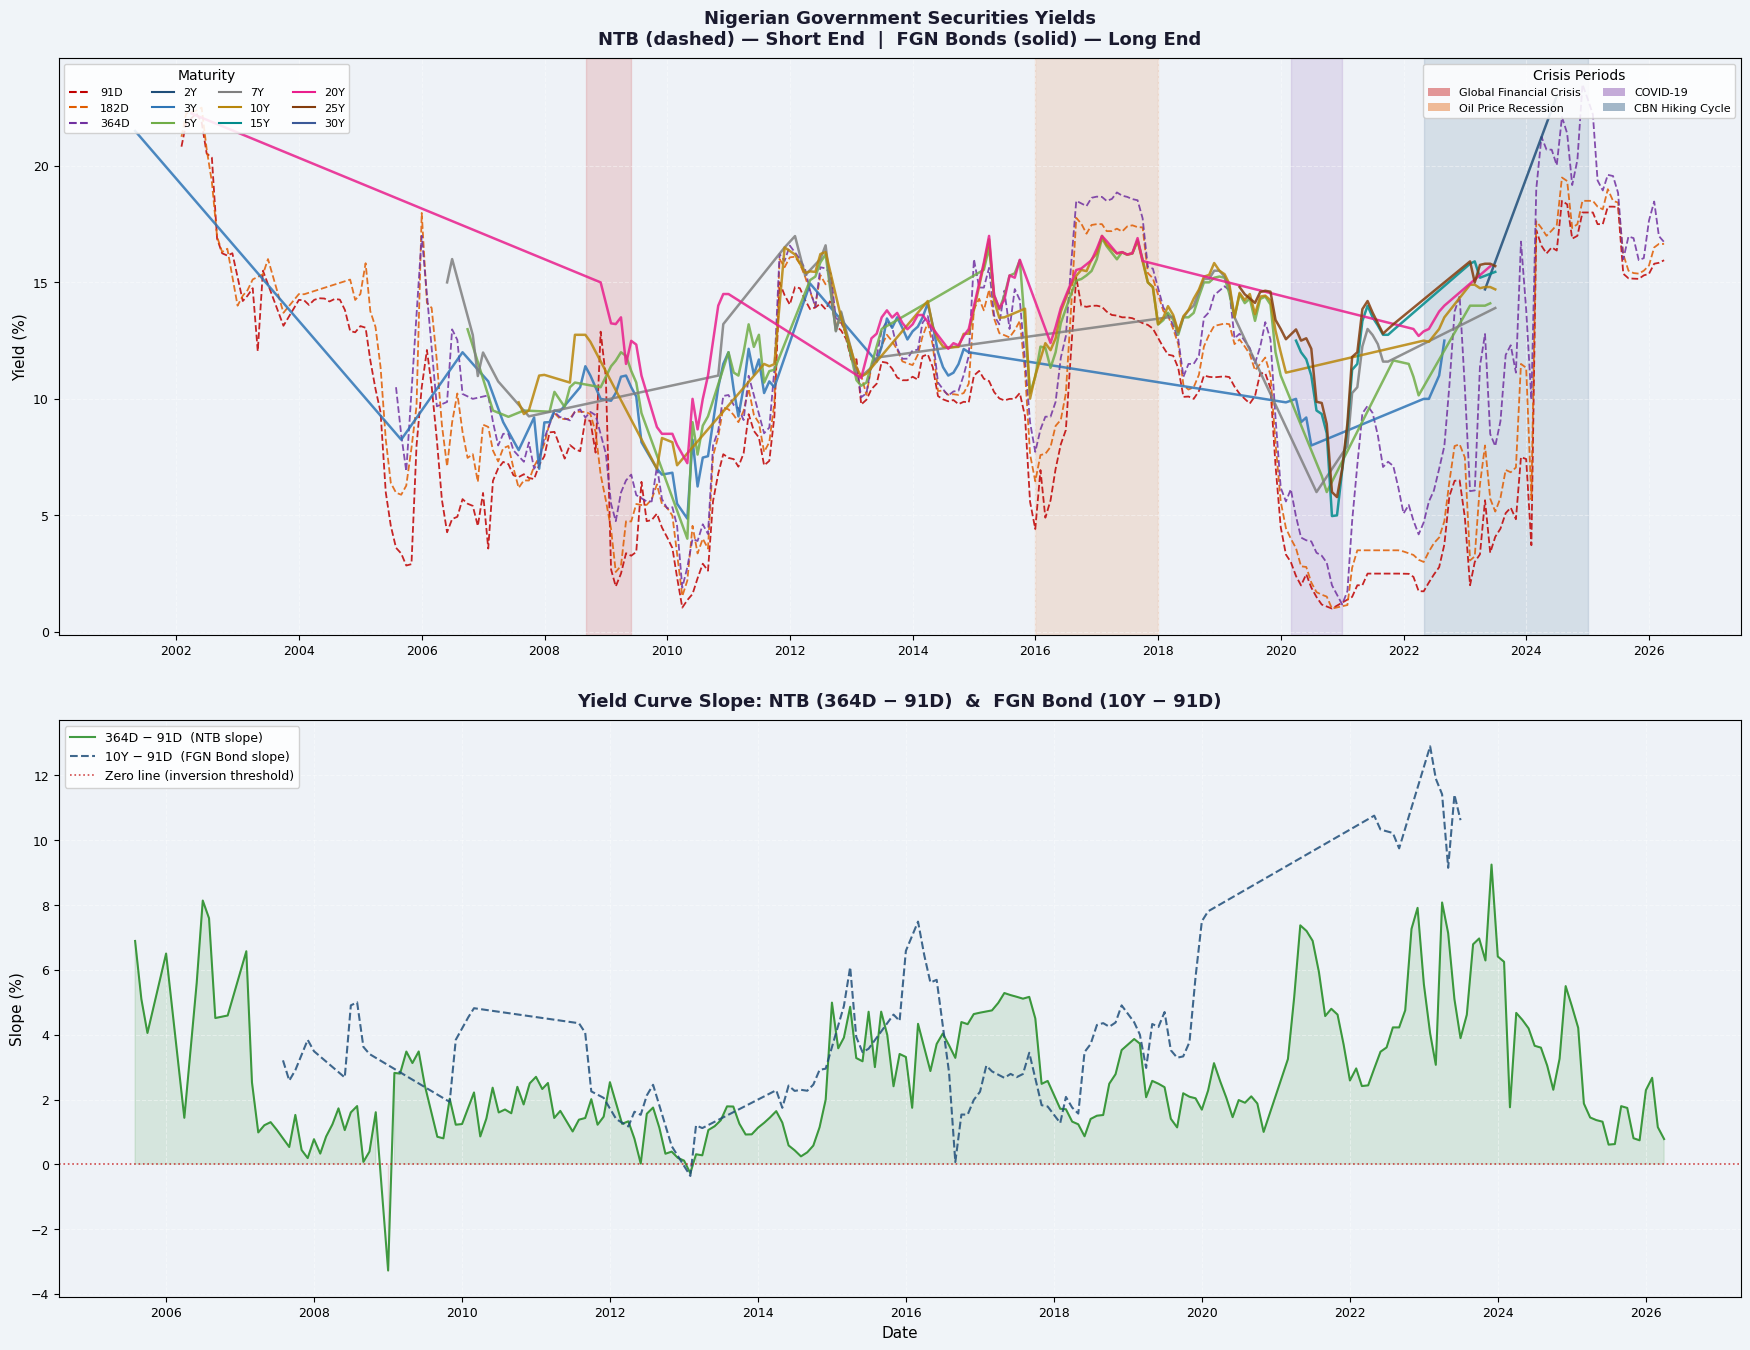

Chart saved.


In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── COLOR MAP — one colour per maturity ───────────────────────────────────
colors = {
    '91D':  '#c00000',    # deep red
    '182D': '#e05c00',    # orange
    '364D': '#7030a0',    # purple
    '2Y':   '#1f4e79',    # dark blue
    '3Y':   '#2e75b6',    # mid blue
    '5Y':   '#70ad47',    # green
    '7Y':   '#7f7f7f',    # grey
    '10Y':  '#b8860b',    # dark gold
    '15Y':  '#008b8b',    # teal
    '20Y':  '#e91e8c',    # pink
    '25Y':  '#843c0c',    # brown
    '30Y':  '#3b5998',    # navy
}

# Short-end tenors (NTB) — dashed lines
short_tenors = ['91D', '182D', '364D']

# Long-end tenors (FGN Bond) — solid lines
long_tenors = ['2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']

# All tenors in order
all_tenors = short_tenors + long_tenors

# ── FIGURE 1: Full time series ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 14))
fig.patch.set_facecolor('#f0f4f8')

# ── Top panel — yield levels (all maturities) ─────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#eef2f7')
ax1.grid(True, linestyle='--', alpha=0.4, color='white')

for col in all_tenors:
    if col not in yield_monthly.columns:
        continue                          # skip if tenor not in data
    data = yield_monthly[col].dropna()
    if data.empty:
        continue

    lw = 1.3 if col in short_tenors else 1.8
    ls = '--' if col in short_tenors else '-'

    ax1.plot(data.index, data,
             color=colors[col],
             linewidth=lw,
             linestyle=ls,
             label=col,
             alpha=0.85)

# Crisis shading
crisis_periods = [
    ('2008-09-01', '2009-06-01', '#c00000', 'Global Financial Crisis'),
    ('2016-01-01', '2017-12-31', '#e05c00', 'Oil Price Recession'),
    ('2020-03-01', '2020-12-31', '#7030a0', 'COVID-19'),
    ('2022-05-01', '2024-12-31', '#1f4e79', 'CBN Hiking Cycle'),
]

for start, end, color, label in crisis_periods:
    ax1.axvspan(pd.to_datetime(start),
                pd.to_datetime(end),
                alpha=0.12, color=color, label=label)

ax1.set_title(
    'Nigerian Government Securities Yields\n'
    'NTB (dashed) — Short End  |  FGN Bonds (solid) — Long End',
    fontsize=13, fontweight='bold', pad=10, color='#1a1a2e'
)
ax1.set_ylabel('Yield (%)', fontsize=11)
ax1.tick_params(labelsize=9)

# ── Split legend: yields vs crisis periods ────────────────────────────────
# Yield lines first
yield_handles = [
    plt.Line2D([0], [0],
               color=colors[c],
               linewidth=1.5,
               linestyle='--' if c in short_tenors else '-',
               label=c)
    for c in all_tenors
    if c in yield_monthly.columns
]

# Crisis patches
from matplotlib.patches import Patch
crisis_handles = [
    Patch(facecolor=color, alpha=0.4, label=label)
    for _, _, color, label in crisis_periods
]

legend1 = ax1.legend(
    handles=yield_handles,
    fontsize=8, ncol=4,
    loc='upper left',
    title='Maturity',
    framealpha=0.88
)
ax1.add_artist(legend1)
ax1.legend(
    handles=crisis_handles,
    fontsize=8, ncol=2,
    loc='upper right',
    title='Crisis Periods',
    framealpha=0.88
)

# ── Bottom panel — slope ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#eef2f7')
ax2.grid(True, linestyle='--', alpha=0.4, color='white')

# Primary slope — 364D minus 91D (short end, NTB)
if '364D' in yield_monthly.columns and '91D' in yield_monthly.columns:
    slope_short = (yield_monthly['364D'] - yield_monthly['91D']).dropna()
    ax2.plot(slope_short.index, slope_short,
             color='#228B22', linewidth=1.5,
             alpha=0.85, label='364D − 91D  (NTB slope)')

# Secondary slope — 10Y minus 2Y (long end, FGN Bond)
if '10Y' in yield_monthly.columns and '91D' in yield_monthly.columns:
    slope_long = (yield_monthly['10Y'] - yield_monthly['91D']).dropna()
    ax2.plot(slope_long.index, slope_long,
             color='#1f4e79', linewidth=1.5,
             linestyle='--', alpha=0.85,
             label='10Y − 91D  (FGN Bond slope)')

ax2.axhline(y=0, color='#c00000', linewidth=1.2,
            linestyle=':', alpha=0.7,
            label='Zero line (inversion threshold)')

# Fill for short slope
if '364D' in yield_monthly.columns and '91D' in yield_monthly.columns:
    ax2.fill_between(
        slope_short.index, slope_short, 0,
        where=(slope_short >= 0),
        alpha=0.12, color='#228B22'
    )
    ax2.fill_between(
        slope_short.index, slope_short, 0,
        where=(slope_short < 0),
        alpha=0.12, color='#c00000'
    )

ax2.set_title(
    'Yield Curve Slope: NTB (364D − 91D)  &  FGN Bond (10Y − 91D)',
    fontsize=13, fontweight='bold', pad=10, color='#1a1a2e'
)
ax2.set_ylabel('Slope (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(fontsize=9, loc='upper left', framealpha=0.88)
ax2.tick_params(labelsize=9)

# ── Format x-axis on both panels ─────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout(pad=2.5)

plt.savefig('nigeria_yield_curve_full.png',dpi=150, bbox_inches='tight', facecolor='#f0f4f8')
plt.show()
print("Chart saved.")

In [27]:
def nelson_siegel(maturity, beta_0, beta_1, beta_2, lambda_param):

    lambda_t = lambda_param * maturity

    exp_term = np.exp(-lambda_t)

    factor1 = (1-exp_term)/lambda_t

    factor2 = factor1 - exp_term

    yield_value =  beta_0 + (beta_1 * factor1) + (beta_2 * factor2)

    return yield_value

In [28]:
def fit_ns_model(yields_df, date, initial_params=None):
    import pandas as pd
    from scipy.optimize import minimize

    date_dt = pd.to_datetime(date)

    # Find the closest date in the index if the exact date is not present
    if date_dt not in yields_df.index:
        if yields_df.index.empty:
            raise ValueError(f"No dates available in yields_df to fit model for {date}.")
        # Manually find the nearest date as 'method' argument might not be supported in older pandas versions
        diff = (yields_df.index - date_dt).days
        nearest_idx = np.argmin(np.abs(diff))
        actual_date_used = yields_df.index[nearest_idx]
        print(f"Warning: Exact date {date} not found in yield curve. Using nearest available date: {actual_date_used.strftime('%Y-%m-%d')}")
        date_dt = actual_date_used

    # Define conceptual maturities and their corresponding column names in yields_df
    conceptual_maturities_years = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30]) # in years
    column_names_for_maturities = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']

    # Get the row for the specified date from yields_df
    yields_for_date = yields_df.loc[date_dt, [col for col in column_names_for_maturities if col in yields_df.columns]]

    mask = ~yields_for_date.isna()
    maturities_clean = conceptual_maturities_years[[column_names_for_maturities.index(col) for col in yields_for_date[mask].index]]
    yields_clean = yields_for_date[mask].values

    if len(yields_clean) < 3: # Need at least 3 points (beta0, beta1, beta2) to fit NS model
        raise ValueError(f"Not enough valid yield points ({len(yields_clean)}) for date {date_dt.strftime('%Y-%m-%d')} to fit Nelson-Siegel model. Need at least 3.")

    if initial_params is None:
        initial_params = [yields_clean.mean(), 0.0, 0.0, 1.0] # Adjusted initial params for better convergence

    def objective(params):
        beta_0, beta_1, beta_2, lambda_param = params
        # Ensure lambda_param is positive
        if lambda_param <= 0: return np.inf
        predicted_yields = nelson_siegel(maturities_clean, beta_0, beta_1, beta_2, lambda_param)
        squared_errors = (yields_clean - predicted_yields) ** 2
        return np.sum(squared_errors)

    bounds = [(None, None), (None, None), (None, None), (0.01, 10)] # lambda must be positive

    result = minimize(objective, initial_params, method='L-BFGS-B', bounds=bounds)

    beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt = result.x

    predicted_yields = nelson_siegel(maturities_clean, beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt)
    rmse = np.sqrt(np.mean((yields_clean - predicted_yields) ** 2))

    return {
        'beta_0': beta_0_opt,
        'beta_1': beta_1_opt,
        'beta_2': beta_2_opt,
        'lambda': lambda_opt,
        'success': result.success,
        'rmse': rmse
    }

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_fitted_yield_curve(yields_df, date, fitted_params):

    print(f"\n{'='*60}")
    print(f"Nelson-Siegel Model Fit Summary for {date}")
    print(f"{'='*60}")
    print(f"β₀ (Level):      {fitted_params['beta_0']:>10.4f}  (Long-term yield level)")
    print(f"β₁ (Slope):      {fitted_params['beta_1']:>10.4f}  (Short-term slope)")
    print(f"β₂ (Curvature):  {fitted_params['beta_2']:>10.4f}  (Medium-term hump)")
    print(f"λ  (Decay):      {fitted_params['lambda']:>10.4f}  (Decay rate)")
    print(f"RMSE:            {fitted_params['rmse']:>10.6f}  (Fit quality)")
    print(f"Optimization:    {'Success' if fitted_params['success'] else 'Failed'}")
    print(f"{'='*60}\n")

    date_dt = pd.to_datetime(date)

    # Find the closest date in the index if the exact date is not present
    if date_dt not in yields_df.index:
        # Manually find the nearest date as 'method' argument might not be supported in older pandas versions
        diff = (yields_df.index - date_dt).days
        nearest_idx = np.argmin(np.abs(diff))
        actual_date_used = yields_df.index[nearest_idx]
        print(f"Warning: Exact date {date} not found for plotting. Using nearest available date: {actual_date_used.strftime('%Y-%m-%d')}")
        date_dt = actual_date_used

    # Define conceptual maturities and their corresponding column names in yields_df
    conceptual_maturities_years = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30]) # in years
    column_names_for_maturities = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']

    # Get the row for the specified date from yields_df
    actual_yields_series = yields_df.loc[date_dt, [col for col in column_names_for_maturities if col in yields_df.columns]]

    mask = ~actual_yields_series.isna()
    actual_maturities_clean = conceptual_maturities_years[[column_names_for_maturities.index(col) for col in actual_yields_series[mask].index]]
    actual_yields_clean = actual_yields_series[mask].values

    if len(actual_yields_clean) == 0:
        print(f"No valid yield points to plot for date {date_dt.strftime('%Y-%m-%d')}.")
        return

    smooth_maturities = np.linspace(actual_maturities_clean.min(),
                                     actual_maturities_clean.max(), 100)
    fitted_yields = nelson_siegel(smooth_maturities,
                                   fitted_params['beta_0'],
                                   fitted_params['beta_1'],
                                   fitted_params['beta_2'],
                                   fitted_params['lambda'])

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot fitted curve (smooth line)
    ax.plot(smooth_maturities, fitted_yields, 'b-', linewidth=2,
            label='Fitted NS Curve', alpha=0.8)

    # Plot actual data points
    ax.scatter(actual_maturities_clean, actual_yields_clean,
               color='red', s=100, zorder=5, label='Actual Yields',
               edgecolors='darkred', linewidths=1.5)

    # Formatting
    ax.set_xlabel('Maturity (years)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
    ax.set_title(f"Nelson-Siegel Fitted Yield Curve - {date_dt.strftime('%Y-%m-%d')}", # Use the actual date used
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig("Nelson-Siegel Fitted Yield Curve", dpi=150, bbox_inches='tight')
    plt.show()


Nelson-Siegel Model Fit Summary for 2015-07-01
β₀ (Level):         20.4000  (Long-term yield level)
β₁ (Slope):        -14.2818  (Short-term slope)
β₂ (Curvature):     13.1194  (Medium-term hump)
λ  (Decay):          1.3289  (Decay rate)
RMSE:              0.000003  (Fit quality)
Optimization:    Success



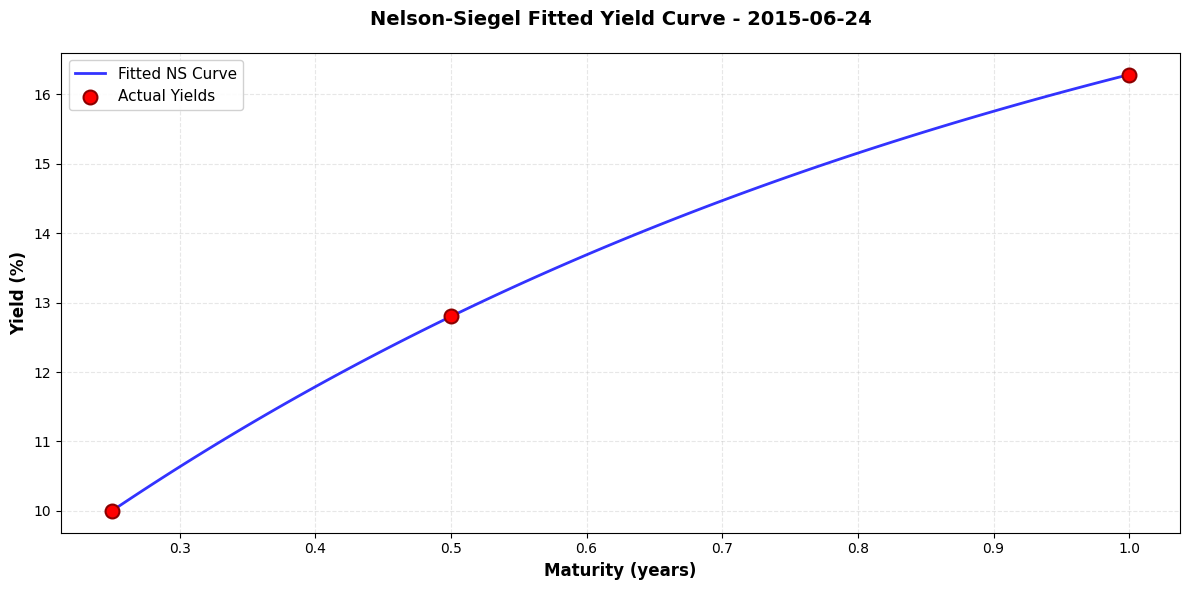

In [48]:
# Fit and plot the yield curve for a specific date
date_to_fit = '2015-07-01'

# Fit the Nelson-Siegel model
fitted_result = fit_ns_model(yield_curve_clean, date_to_fit)

# Plot the results
plot_fitted_yield_curve(yield_curve_clean, date_to_fit, fitted_result)


Nelson-Siegel Model Fit Summary for 2025-03-13
β₀ (Level):         18.4965  (Long-term yield level)
β₁ (Slope):         -3.0418  (Short-term slope)
β₂ (Curvature):      3.4625  (Medium-term hump)
λ  (Decay):          2.6041  (Decay rate)
RMSE:              0.000021  (Fit quality)
Optimization:    Success



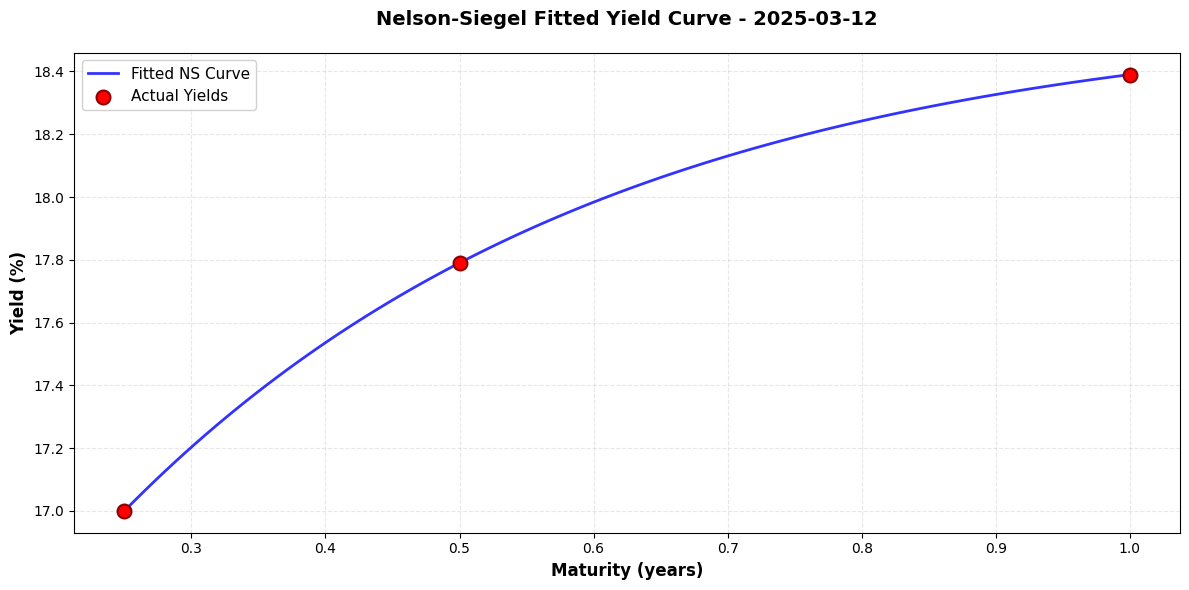

In [50]:
# Fit and plot the yield curve for a specific date
date_to_fit = '2025-03-13'

# Fit the Nelson-Siegel model
fitted_result = fit_ns_model(yield_curve_clean, date_to_fit)

# Plot the results
plot_fitted_yield_curve(yield_curve_clean, date_to_fit, fitted_result)


In [32]:
def standardize_yields(yields):

    # Calculate means and standard deviations for each yield column
    yield_means = yields.mean()
    yield_stds = yields.std()

    # Apply standardization formula: Z = (X - μ) / σ
    standardized_yields = (yields - yield_means) / yield_stds

    return standardized_yields

In [33]:
def compute_pca_variance_explained(standardized_yields):

    # 1. Drop rows with NaN values.
    # This ensures that for the remaining rows, all values are non-NaN.
    standardized_yields_rows_cleaned = standardized_yields.dropna()

    # 2. Drop columns that have fewer than 2 observations after row cleaning.
    # (A column must have at least 2 values to compute variance/covariance)
    # count() returns non-NaN counts for each column.
    valid_columns_mask = standardized_yields_rows_cleaned.count() >= 2
    standardized_yields_final = standardized_yields_rows_cleaned.loc[:, valid_columns_mask]

    # 3. Check if there's enough data left for PCA
    if standardized_yields_final.empty or \
       standardized_yields_final.shape[0] < 2 or \
       standardized_yields_final.shape[1] < 2:
        raise ValueError("Not enough complete and valid data points (rows or columns) after cleaning to compute PCA.")

    # Calculate the covariance matrix
    cov_matrix = standardized_yields_final.cov()

    # Calculate eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Sort eigenvalues in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_indices]

    # Calculate total variance
    total_variance = np.sum(eigenvalues_sorted)

    # Calculate variance explained percentage
    variance_explained_pct = (eigenvalues_sorted / total_variance) * 100

    # Create DataFrame with proper index starting from 1
    n_components = len(eigenvalues_sorted)
    result_df = pd.DataFrame({
        'Eigenvalue': eigenvalues_sorted,
        'Variance Explained (%)': variance_explained_pct
    }, index=range(1, n_components + 1))

    return result_df

In [34]:
# Manually select a set of reliably dense columns for PCA
dense_columns = ['91D', '182D', '364D'] # Choose the 3 most consistently available short-term tenors

# Filter yield_curve_filled to include only these dense columns
yield_curve_dense = yield_curve_filled[dense_columns]

# Impute remaining NaNs for PCA. Interpolation first, then ffill/bfill to catch edges.
yield_curve_dense_imputed = yield_curve_dense.interpolate(method='linear', limit_direction='both', limit_area='inside')
yield_curve_dense_imputed = yield_curve_dense_imputed.ffill().bfill()

# Now standardize and compute PCA variance explained using the dense and imputed data
standardized_data = standardize_yields(yield_curve_dense_imputed)
pca_result = compute_pca_variance_explained(standardized_data)
pca_result

,Eigenvalue,Variance Explained (%)
1,2.474248,82.474933
2,0.475234,15.841135
3,0.050518,1.683932


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# ── Nelson-Siegel formula (same as your original notebook) ────────────────
def nelson_siegel(maturity, beta_0, beta_1, beta_2, lambda_param):
    """Compute NS yield at a given maturity (in years)."""
    lambda_t  = lambda_param * maturity
    exp_term  = np.exp(-lambda_t)
    factor1   = (1 - exp_term) / lambda_t      # loading for beta_1
    factor2   = factor1 - exp_term             # loading for beta_2
    return beta_0 + (beta_1 * factor1) + (beta_2 * factor2)

# ── Mapping: column name → maturity in years ──────────────────────────────
TENOR_YEARS = {
    '91D': 0.25, '182D': 0.5, '364D': 1.0,
    '2Y': 2,     '3Y': 3,     '5Y': 5,
    '7Y': 7,     '10Y': 10,   '15Y': 15,
    '20Y': 20,   '25Y': 25,   '30Y': 30
}

# ── Fit NS for a single row of yields ─────────────────────────────────────
def fit_ns_row(row):
    """
    Given one row (a date's yields across tenors),
    fit Nelson-Siegel and return [beta_0, beta_1, beta_2, lambda, rmse].
    Returns NaN row if fewer than 3 valid data points.
    """
    # Extract only the tenors that have a valid yield value
    valid = {t: row[t] for t in TENOR_YEARS if t in row.index and not pd.isna(row[t])}

    # Need at least 3 points to fit 3 beta parameters
    if len(valid) < 3:
        return pd.Series([np.nan]*5, index=['beta_0','beta_1','beta_2','lambda','rmse'])

    maturities = np.array([TENOR_YEARS[t] for t in valid])
    yields     = np.array(list(valid.values()))

    # Objective: minimise sum of squared errors between actual and fitted yields
    def objective(params):
        b0, b1, b2, lam = params
        if lam <= 0:
            return np.inf
        fitted = nelson_siegel(maturities, b0, b1, b2, lam)
        return np.sum((yields - fitted)**2)

    # Starting guess: mean yield, zero slope, zero curvature, lambda=1
    x0     = [yields.mean(), 0.0, 0.0, 1.0]
    bounds = [(None, None), (None, None), (None, None), (0.01, 10)]

    result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
    b0, b1, b2, lam = result.x

    fitted = nelson_siegel(maturities, b0, b1, b2, lam)
    rmse   = np.sqrt(np.mean((yields - fitted)**2))

    return pd.Series([b0, b1, b2, lam, rmse],
                     index=['beta_0','beta_1','beta_2','lambda','rmse'])

print("Functions defined. Now fitting Nelson-Siegel across all dates...")
print("This may take 1–2 minutes for ~1,400 dates.")

Functions defined. Now fitting Nelson-Siegel across all dates...
This may take 1–2 minutes for ~1,400 dates.


In [36]:
# ── Apply NS fitting to every row in the yield curve ──────────────────────
# yield_curve_clean comes from your original notebook
# We use a monthly resampled version for speed and cleaner visualisation

yield_monthly = yield_curve_clean.resample('ME').mean()

# Fit NS across every month — this creates a DataFrame with one row per month
ns_params = yield_monthly.apply(fit_ns_row, axis=1)

# Remove rows where fitting failed (not enough data points)
ns_params = ns_params.dropna(subset=['beta_0'])

# Filter out implausible fits (RMSE > 2 means the model didn't converge well)
ns_params = ns_params[ns_params['rmse'] < 2.0]

print(f"Successfully fitted NS model for {len(ns_params)} months")
print(f"Date range: {ns_params.index.min().date()} to {ns_params.index.max().date()}")
print("\nSample of fitted parameters:")
print(ns_params.head(10).round(4))

Successfully fitted NS model for 242 months
Date range: 2005-07-31 to 2026-03-31

Sample of fitted parameters:
               beta_0    beta_1    beta_2  lambda    rmse
auction_date                                             
2005-07-31    83.7043  -82.5329   87.8416  0.1161  0.0000
2005-08-31     2.9680   -3.4365   26.1557  1.2577  0.0000
2005-09-30     7.0383  -28.6254   27.5954  7.9880  0.0000
2005-12-31    15.0381 -123.3661  143.0322  9.9900  0.0000
2006-03-31     6.9781  -78.5595  105.6259  9.9995  0.0000
2006-05-31    15.9122  -15.2329    0.0000  2.3249  0.1250
2006-06-30    16.2907  -18.4704   13.9241  2.2345  0.0000
2006-07-31    13.6955  -27.0329   21.3288  5.3419  0.0000
2006-08-31    12.6271  -13.5092   -0.0003  6.1456  0.1438
2006-09-30    13.8662  -11.2759    1.7768  2.1683  0.0000


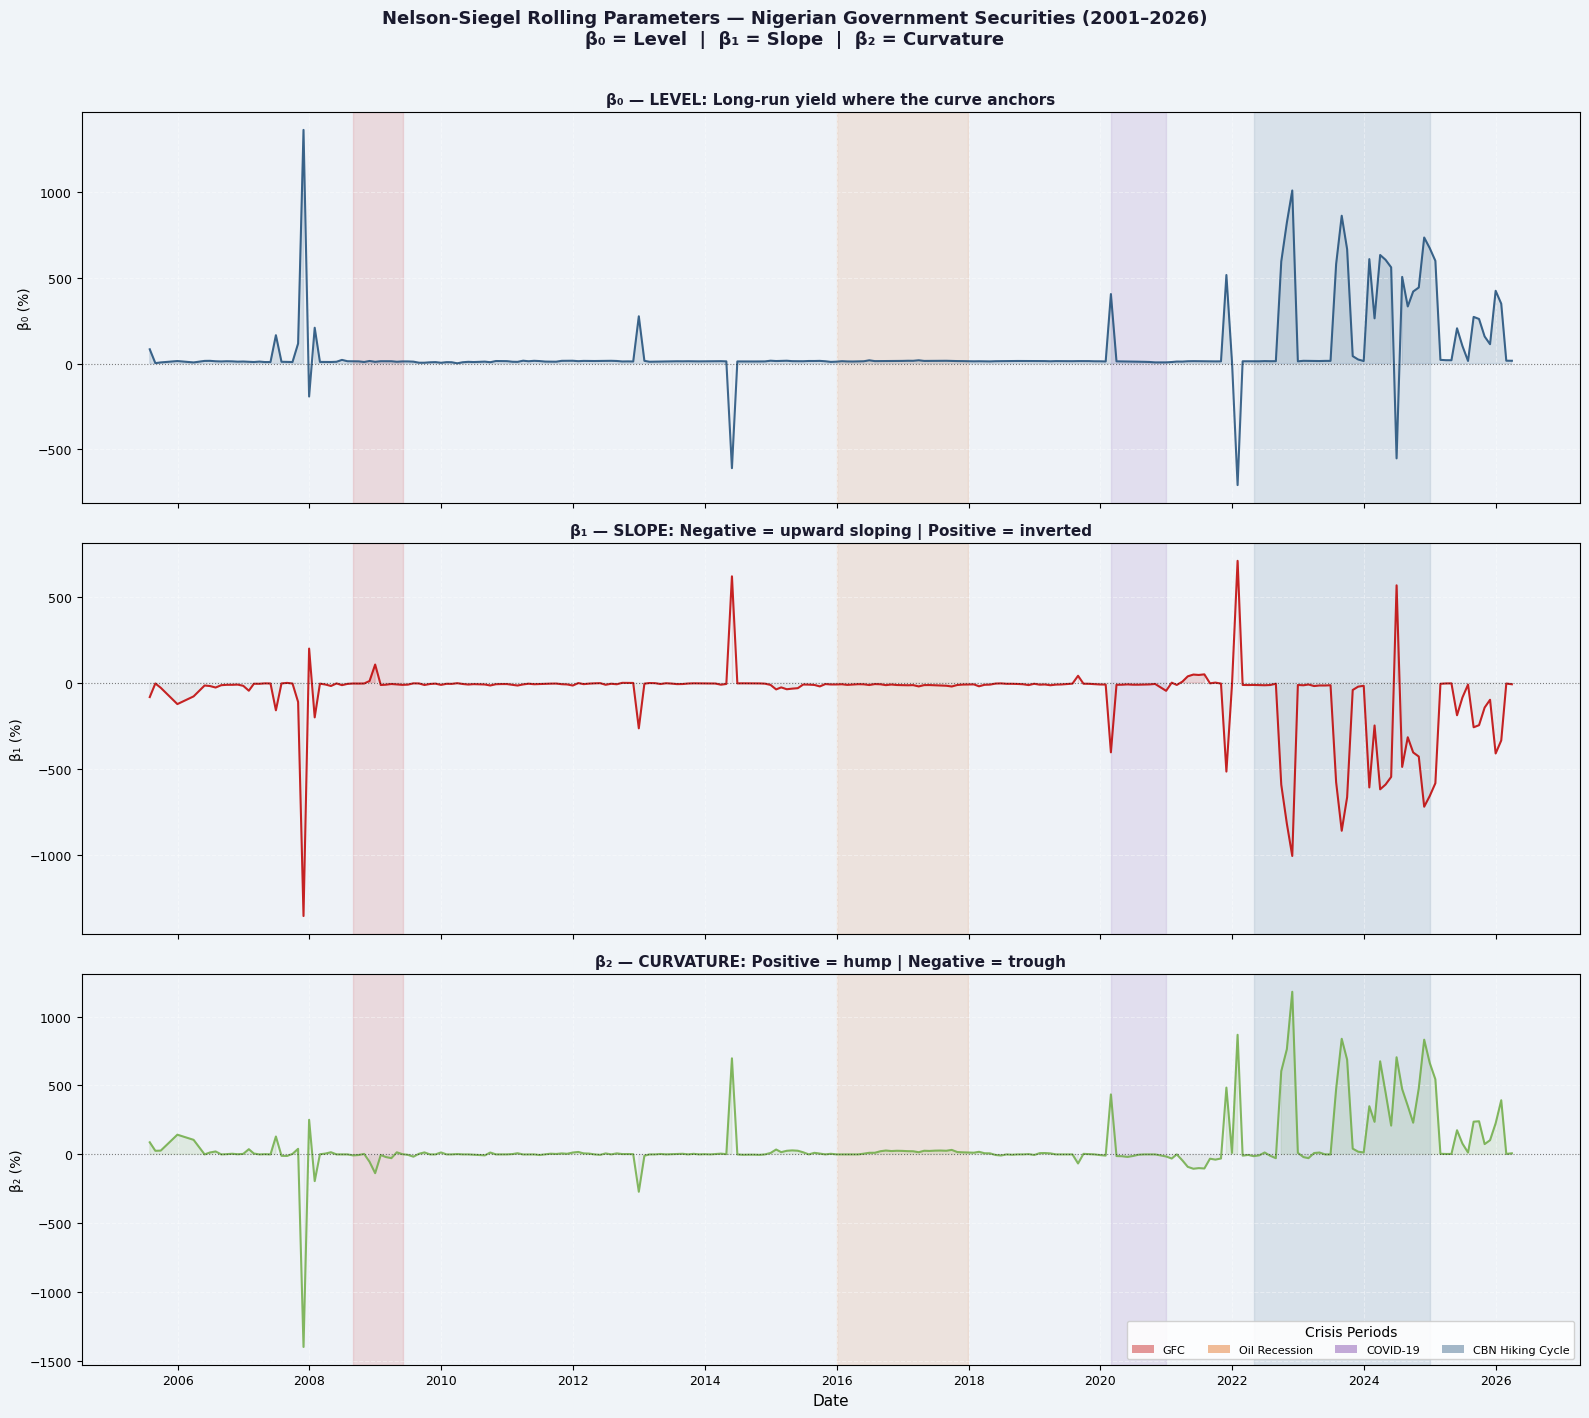

Chart saved as ns_rolling_parameters.png


In [37]:
# ── PLOT: Rolling NS Parameters Over Time ─────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.patch.set_facecolor('#f0f4f8')
fig.suptitle(
    'Nelson-Siegel Rolling Parameters — Nigerian Government Securities (2001–2026)\n'
    'β₀ = Level  |  β₁ = Slope  |  β₂ = Curvature',
    fontsize=13, fontweight='bold', y=1.01, color='#1a1a2e'
)

# Crisis shading — applied to all three panels
CRISIS_PERIODS = [
    ('2008-09-01', '2009-06-01', '#c00000', 'GFC'),
    ('2016-01-01', '2017-12-31', '#e05c00', 'Oil Recession'),
    ('2020-03-01', '2020-12-31', '#7030a0', 'COVID-19'),
    ('2022-05-01', '2024-12-31', '#1f4e79', 'CBN Hiking Cycle'),
]

param_config = [
    # (column,    colour,    y-label,                    title)
    ('beta_0', '#1f4e79', 'β₀ (%)',
     'β₀ — LEVEL: Long-run yield where the curve anchors'),
    ('beta_1', '#c00000', 'β₁ (%)',
     'β₁ — SLOPE: Negative = upward sloping | Positive = inverted'),
    ('beta_2', '#70ad47', 'β₂ (%)',
     'β₂ — CURVATURE: Positive = hump | Negative = trough'),
]

for ax, (col, color, ylabel, title) in zip(axes, param_config):
    ax.set_facecolor('#eef2f7')
    ax.grid(True, linestyle='--', alpha=0.4, color='white')

    # Plot the parameter
    ax.plot(ns_params.index, ns_params[col],
            color=color, linewidth=1.5, alpha=0.85)

    # Fill above/below zero
    ax.fill_between(ns_params.index, ns_params[col], 0,
                    where=(ns_params[col] >= 0),
                    alpha=0.12, color=color)
    ax.fill_between(ns_params.index, ns_params[col], 0,
                    where=(ns_params[col] < 0),
                    alpha=0.08, color='grey')

    # Zero reference line
    ax.axhline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.5)

    # Crisis shading
    for start, end, c, label in CRISIS_PERIODS:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                   alpha=0.10, color=c)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=6, color='#1a1a2e')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)

# Crisis legend on the bottom panel only
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, alpha=0.4, label=lbl)
                  for _, _, c, lbl in CRISIS_PERIODS]
axes[-1].legend(handles=legend_handles, fontsize=8, ncol=4,
                loc='lower right', framealpha=0.88, title='Crisis Periods')
axes[-1].set_xlabel('Date', fontsize=11)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('ns_rolling_parameters.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("Chart saved as ns_rolling_parameters.png")

In [38]:
# ── INTERPRETATION SUMMARY ────────────────────────────────────────────────
# Print a summary of what each parameter averaged across the key regimes

regimes = {
    'Pre-Crisis (2001–2008)':      ('2001-01-01', '2008-12-31'),
    'Post-Crisis (2009–2015)':     ('2009-01-01', '2015-12-31'),
    'Oil Recession (2016–2017)':   ('2016-01-01', '2017-12-31'),
    'Stability (2018–2021)':       ('2018-01-01', '2021-12-31'),
    'CBN Hiking (2022–2024)':      ('2022-01-01', '2024-12-31'),
}

print(f"{'Regime':<30} {'β₀ (Level)':>12} {'β₁ (Slope)':>12} {'β₂ (Curv)':>12}")
print("-" * 70)

for name, (start, end) in regimes.items():
    mask = (ns_params.index >= start) & (ns_params.index <= end)
    sub  = ns_params[mask]
    if len(sub) == 0:
        continue
    b0 = sub['beta_0'].mean()
    b1 = sub['beta_1'].mean()
    b2 = sub['beta_2'].mean()
    print(f"{name:<30} {b0:>12.2f} {b1:>12.2f} {b2:>12.2f}")

print()
print("INTERPRETATION GUIDE:")
print("  β₀ > 0       → curve has positive long-run anchor (normal)")
print("  β₁ < 0       → upward sloping curve (short rates < long rates)")
print("  β₁ close to 0→ flat curve (short and long rates converging)")
print("  β₂ > 0       → hump shape (medium term yields elevated)")
print("  β₂ < 0       → trough shape (medium term yields depressed)")

Regime                           β₀ (Level)   β₁ (Slope)    β₂ (Curv)
----------------------------------------------------------------------
Pre-Crisis (2001–2008)                56.98       -56.37       -23.80
Post-Crisis (2009–2015)                8.54        -3.85         8.18
Oil Recession (2016–2017)             15.36       -12.33        18.07
Stability (2018–2021)                 32.33       -22.11         5.80
CBN Hiking (2022–2024)               259.87      -253.65       307.69

INTERPRETATION GUIDE:
  β₀ > 0       → curve has positive long-run anchor (normal)
  β₁ < 0       → upward sloping curve (short rates < long rates)
  β₁ close to 0→ flat curve (short and long rates converging)
  β₂ > 0       → hump shape (medium term yields elevated)
  β₂ < 0       → trough shape (medium term yields depressed)


In [39]:
# ── COMPUTE BID-TO-COVER RATIO ─────────────────────────────────────────────
# df_clean comes from your original notebook

# Filter to NTB Primary Market only (where BTC is most meaningful)
ntb_df = df_clean[
    (df_clean['security_type_clean'] == 'NTB') &
    (df_clean['auction'].str.contains('Primary', na=False))
].copy()

# Convert columns to numeric (they may be strings from the raw CSV)
ntb_df['totalSubscription'] = pd.to_numeric(ntb_df['totalSubscription'], errors='coerce')
ntb_df['amtOffered']        = pd.to_numeric(ntb_df['amtOffered'],        errors='coerce')
ntb_df['yield_pct']         = pd.to_numeric(ntb_df['yield_pct'],         errors='coerce')

# Compute BTC — guard against division by zero
ntb_df['btc'] = np.where(
    ntb_df['amtOffered'] > 0,
    ntb_df['totalSubscription'] / ntb_df['amtOffered'],
    np.nan
)

# Remove outliers (BTC > 20 is likely a data error)
ntb_df = ntb_df[(ntb_df['btc'] > 0) & (ntb_df['btc'] < 20)]

print(f"NTB Primary Market records: {len(ntb_df)}")
print(f"\nBid-to-Cover summary by tenor:")
print(ntb_df.groupby('tenor_bucket')['btc'].describe().round(2))

NTB Primary Market records: 1715

Bid-to-Cover summary by tenor:
              count  mean   std   min   25%   50%   75%    max
tenor_bucket                                                  
182D          663.0  2.05  2.03  0.07  1.01  1.52  2.36  19.43
2Y              2.0  1.62  0.40  1.33  1.47  1.62  1.76   1.90
30Y             2.0  0.44  0.56  0.05  0.25  0.44  0.64   0.84
364D          418.0  3.39  2.71  0.21  1.66  2.64  4.15  18.87
3Y              1.0  2.65   NaN  2.65  2.65  2.65  2.65   2.65
5Y              1.0  4.75   NaN  4.75  4.75  4.75  4.75   4.75
91D           628.0  1.92  1.92  0.05  1.01  1.36  2.05  14.49


In [40]:
# ── MONTHLY AGGREGATION ────────────────────────────────────────────────────
# Compute monthly average BTC and yield per tenor bucket

ntb_monthly = (
    ntb_df
    .set_index('auction_date')
    .groupby('tenor_bucket')
    .resample('ME')[['btc', 'yield_pct']]
    .mean()
    .reset_index()
)

# Focus on the 3 NTB tenors
tenor_colors = {'91D': '#c00000', '182D': '#e05c00', '364D': '#7030a0'}

print("Monthly data ready. Shape:", ntb_monthly.shape)

Monthly data ready. Shape: (843, 4)


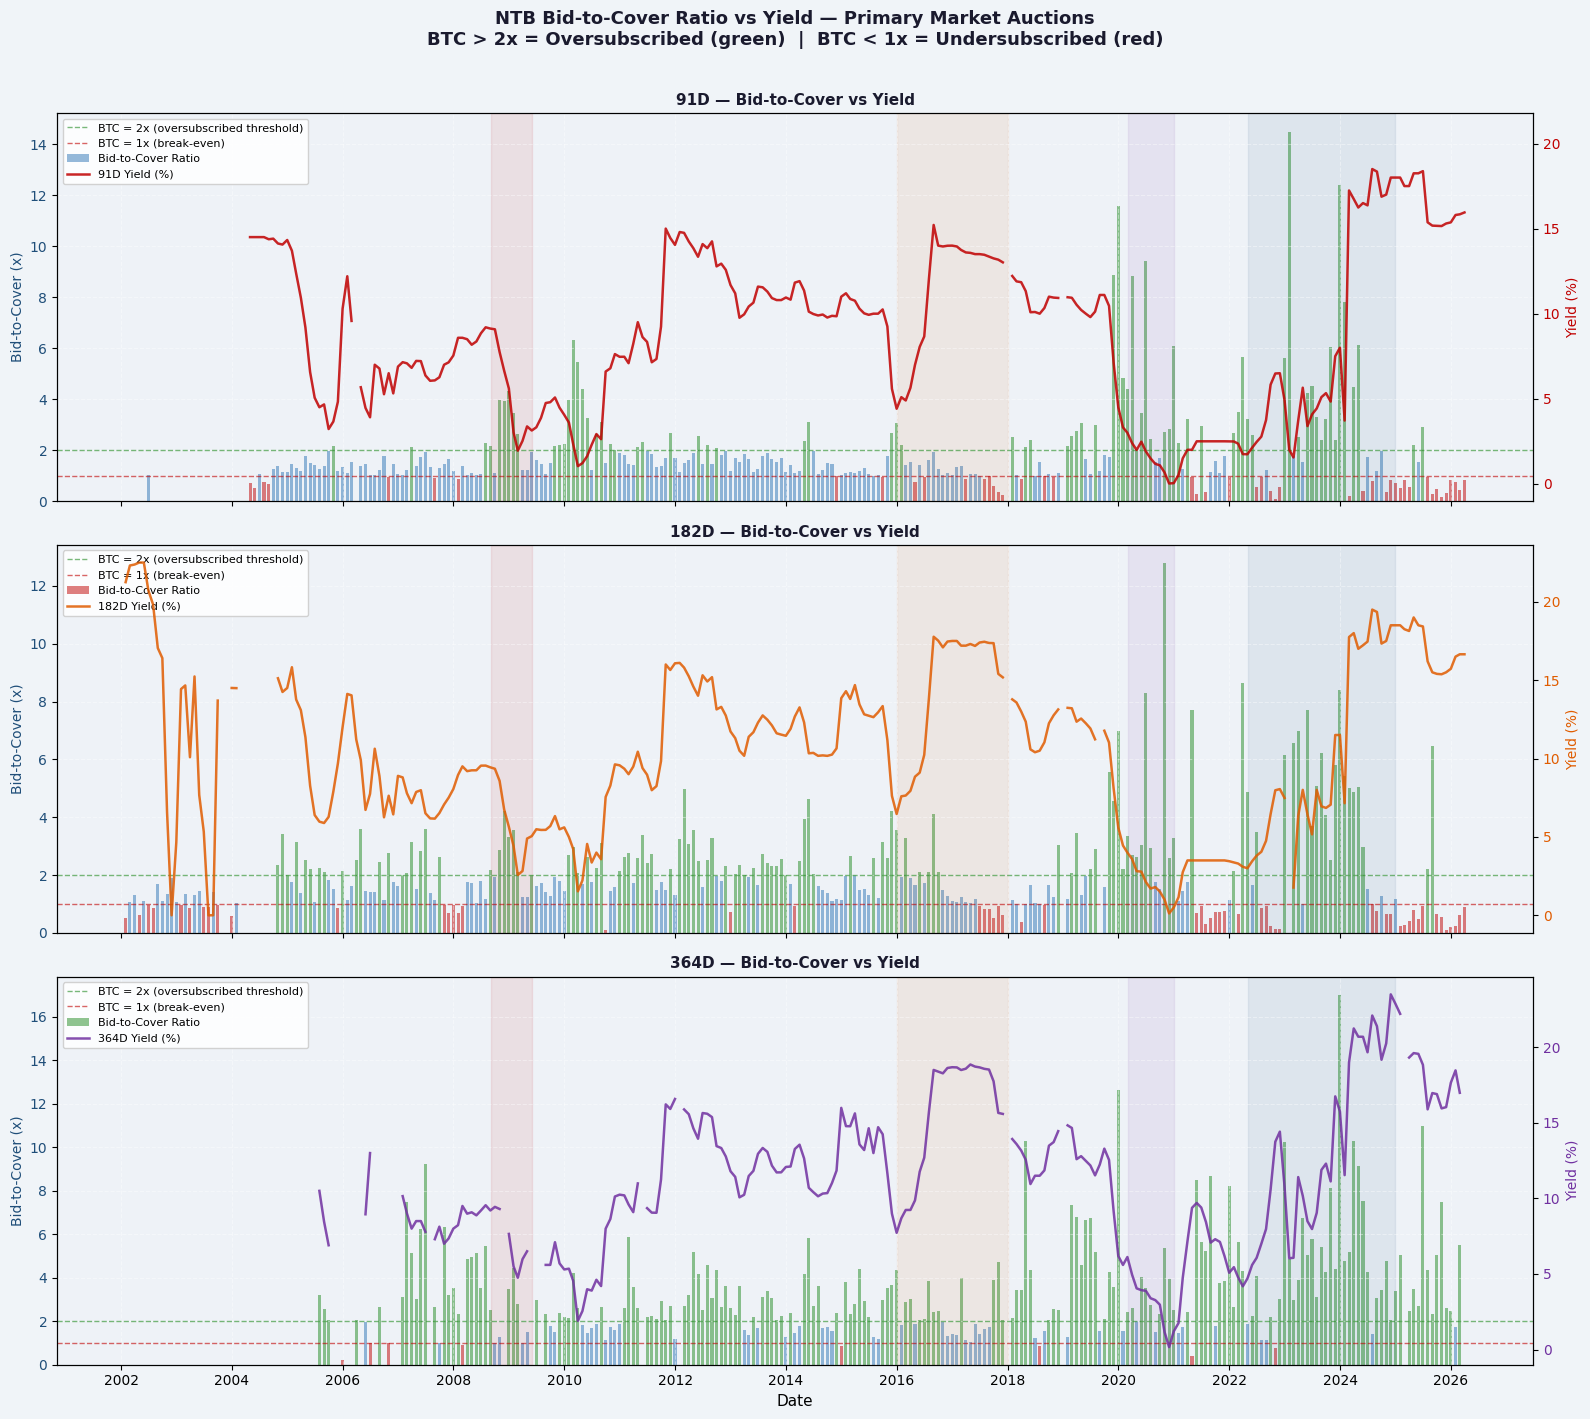

Chart saved as ntb_btc_vs_yield.png


In [41]:
# ── PLOT 1: BTC Over Time with Yield Overlay ──────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.patch.set_facecolor('#f0f4f8')
fig.suptitle(
    'NTB Bid-to-Cover Ratio vs Yield — Primary Market Auctions\n'
    'BTC > 2x = Oversubscribed (green)  |  BTC < 1x = Undersubscribed (red)',
    fontsize=13, fontweight='bold', y=1.01, color='#1a1a2e'
)

for ax, tenor in zip(axes, ['91D', '182D', '364D']):
    sub = ntb_monthly[ntb_monthly['tenor_bucket'] == tenor].set_index('auction_date')

    if sub.empty:
        ax.set_title(f'{tenor} — no data')
        continue

    ax.set_facecolor('#eef2f7')
    ax.grid(True, linestyle='--', alpha=0.4, color='white')

    color = tenor_colors[tenor]

    # ── BTC bars (left axis) ──────────────────────────────────────────────
    # Colour bars green if oversubscribed (BTC >= 2), red if weak (BTC < 1),
    # and blue otherwise
    bar_colors = [
        '#228B22' if v >= 2 else ('#c00000' if v < 1 else '#2e75b6')
        for v in sub['btc'].fillna(0)
    ]
    ax.bar(sub.index, sub['btc'], color=bar_colors, alpha=0.5,
           width=20, label='Bid-to-Cover Ratio')

    # Reference lines
    ax.axhline(2.0, color='#228B22', linewidth=1.0, linestyle='--', alpha=0.6,
               label='BTC = 2x (oversubscribed threshold)')
    ax.axhline(1.0, color='#c00000', linewidth=1.0, linestyle='--', alpha=0.6,
               label='BTC = 1x (break-even)')

    ax.set_ylabel('Bid-to-Cover (x)', fontsize=10, color='#1f4e79')
    ax.tick_params(axis='y', labelcolor='#1f4e79')

    # ── Yield line (right axis) ───────────────────────────────────────────
    ax2 = ax.twinx()
    ax2.plot(sub.index, sub['yield_pct'],
             color=color, linewidth=1.8, alpha=0.85,
             label=f'{tenor} Yield (%)')
    ax2.set_ylabel('Yield (%)', fontsize=10, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    # Crisis shading
    for start, end, c, _ in CRISIS_PERIODS:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
                   alpha=0.08, color=c)

    ax.set_title(
        f'{tenor} — Bid-to-Cover vs Yield',
        fontsize=11, fontweight='bold', pad=6, color='#1a1a2e'
    )

    # Combine legends from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=8, loc='upper left', framealpha=0.88)

axes[-1].set_xlabel('Date', fontsize=11)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('ntb_btc_vs_yield.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("Chart saved as ntb_btc_vs_yield.png")

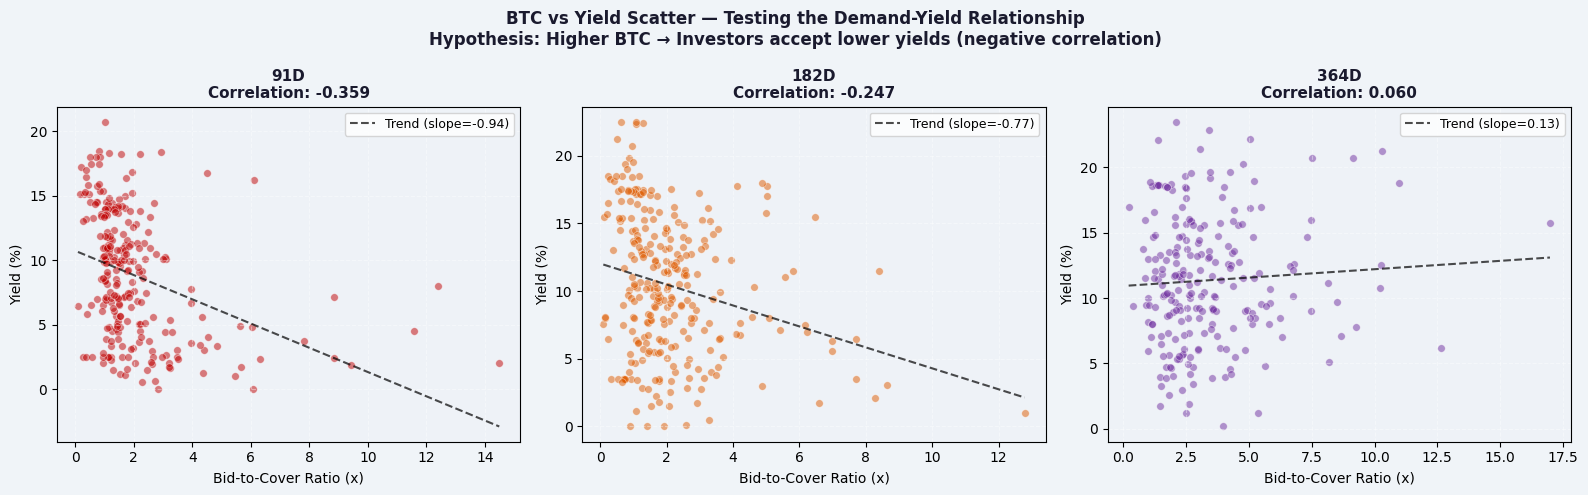

Chart saved as btc_yield_scatter.png

INTERPRETATION:
  Negative correlation → hypothesis confirmed (high demand lowers yields)
  Positive correlation → demand is chasing yield (investors demand MORE when yields are high)
  Near zero           → BTC and yield are unrelated in this tenor


In [42]:
# ── PLOT 2: BTC vs Yield Scatter — Does high demand → lower yields? ───────
# This tests the economic hypothesis: when demand is strong (high BTC),
# investors accept lower yields.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f0f4f8')
fig.suptitle(
    'BTC vs Yield Scatter — Testing the Demand-Yield Relationship\n'
    'Hypothesis: Higher BTC → Investors accept lower yields (negative correlation)',
    fontsize=12, fontweight='bold', color='#1a1a2e'
)

for ax, tenor in zip(axes, ['91D', '182D', '364D']):
    sub = ntb_monthly[ntb_monthly['tenor_bucket'] == tenor].dropna(
        subset=['btc', 'yield_pct']
    )

    if len(sub) < 10:
        ax.set_title(f'{tenor} — insufficient data')
        continue

    color = tenor_colors[tenor]

    ax.scatter(sub['btc'], sub['yield_pct'],
               color=color, alpha=0.5, s=30, edgecolors='white', linewidth=0.5)

    # Fit a trend line
    z = np.polyfit(sub['btc'].dropna(), sub['yield_pct'].dropna(), 1)
    p = np.poly1d(z)
    x_range = np.linspace(sub['btc'].min(), sub['btc'].max(), 100)
    ax.plot(x_range, p(x_range), color='black', linewidth=1.5,
            linestyle='--', alpha=0.7, label=f'Trend (slope={z[0]:.2f})')

    # Pearson correlation
    corr = sub['btc'].corr(sub['yield_pct'])

    ax.set_facecolor('#eef2f7')
    ax.grid(True, linestyle='--', alpha=0.4, color='white')
    ax.set_title(f'{tenor}\nCorrelation: {corr:.3f}',
                 fontsize=11, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('Bid-to-Cover Ratio (x)', fontsize=10)
    ax.set_ylabel('Yield (%)', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('btc_yield_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("Chart saved as btc_yield_scatter.png")
print()
print("INTERPRETATION:")
print("  Negative correlation → hypothesis confirmed (high demand lowers yields)")
print("  Positive correlation → demand is chasing yield (investors demand MORE when yields are high)")
print("  Near zero           → BTC and yield are unrelated in this tenor")

In [43]:
# ── DEFINE REGIMES ─────────────────────────────────────────────────────────

REGIMES = {
    'Pre-Crisis\n(2001–2008)':       ('2001-01-01', '2008-12-31', '#2e75b6'),
    'Post-Crisis\n(2009–2015)':      ('2009-01-01', '2015-12-31', '#70ad47'),
    'Oil Recession\n(2016–2017)':    ('2016-01-01', '2017-12-31', '#c00000'),
    'Stability\n(2018–2021)':        ('2018-01-01', '2021-12-31', '#7030a0'),
    'CBN Hiking Cycle\n(2022–2024)': ('2022-01-01', '2024-12-31', '#e05c00'),
}

# Tenors in maturity order
PLOT_TENORS = ['91D', '182D', '364D', '2Y', '3Y', '5Y', '7Y', '10Y', '15Y', '20Y']
MATURITY_LABELS = ['0.25', '0.5', '1', '2', '3', '5', '7', '10', '15', '20']
MATURITY_X = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20]

# Compute mean yield for each tenor within each regime
regime_curves = {}

for label, (start, end, color) in REGIMES.items():
    mask = (
        (yield_curve_clean.index >= start) &
        (yield_curve_clean.index <= end)
    )
    sub  = yield_curve_clean[mask]
    means = sub[[t for t in PLOT_TENORS if t in sub.columns]].mean()
    regime_curves[label] = {'means': means, 'color': color,
                             'start': start, 'end': end}

print("Average yields per regime:")
summary_df = pd.DataFrame(
    {label: data['means'] for label, data in regime_curves.items()}
).T
print(summary_df.round(2))

Average yields per regime:
tenor_bucket                     91D   182D   364D     2Y     3Y     5Y  \
Pre-Crisis\n(2001–2008)        10.09  11.00  10.23    NaN  10.33  10.23   
Post-Crisis\n(2009–2015)        8.66   9.74  11.01    NaN  10.71  12.15   
Oil Recession\n(2016–2017)     11.80  14.77  15.80    NaN    NaN  14.84   
Stability\n(2018–2021)          6.45   7.41   9.01    NaN   9.21  13.27   
CBN Hiking Cycle\n(2022–2024)   7.86   9.45  12.87  18.85  10.88  12.67   

tenor_bucket                      7Y    10Y    15Y    20Y  
Pre-Crisis\n(2001–2008)        12.39  11.21    NaN  18.62  
Post-Crisis\n(2009–2015)       13.53  12.76    NaN  12.57  
Oil Recession\n(2016–2017)       NaN  15.17    NaN  15.59  
Stability\n(2018–2021)         12.84  14.08  10.77    NaN  
CBN Hiking Cycle\n(2022–2024)  13.90  14.03  15.59  13.58  


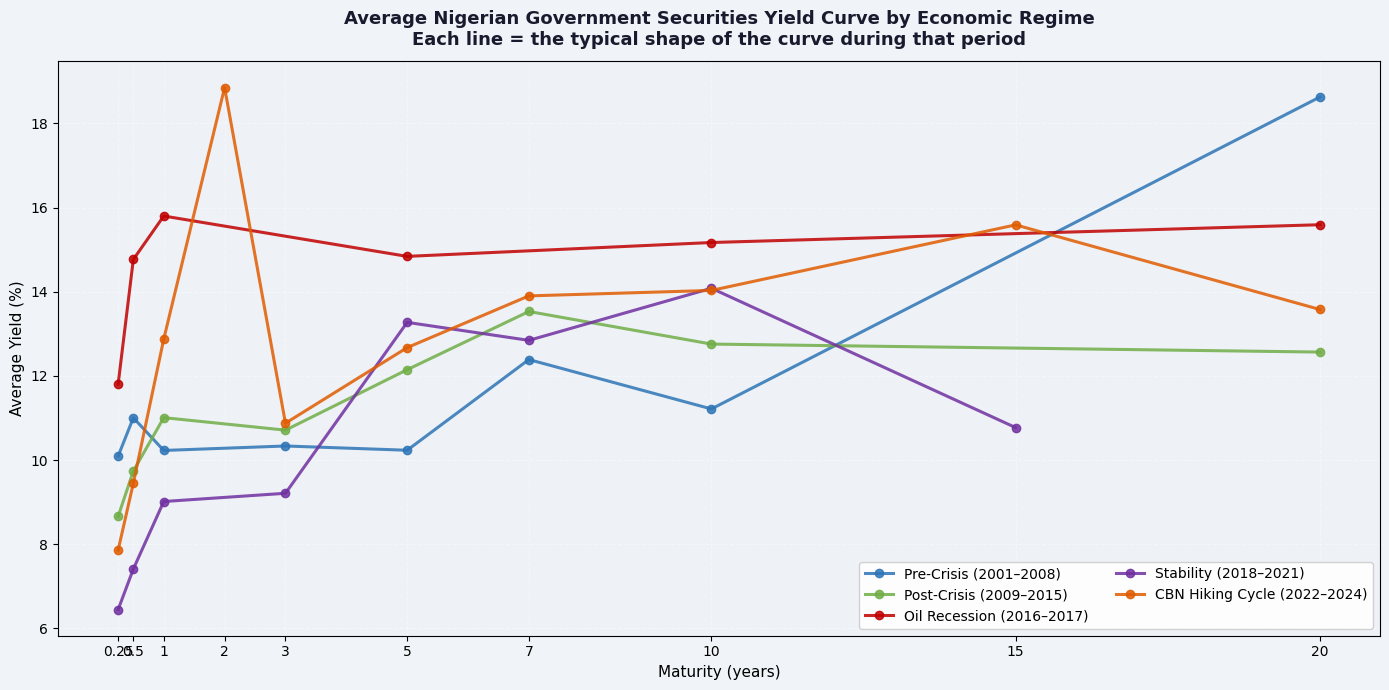

Chart saved as regime_yield_curves.png


In [44]:
# ── PLOT 1: Average Yield Curve Per Regime (snapshot view) ────────────────

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#f0f4f8')
ax.set_facecolor('#eef2f7')
ax.grid(True, linestyle='--', alpha=0.4, color='white')

for label, data in regime_curves.items():
    means  = data['means']
    color  = data['color']

    # Only keep tenors that have data in this regime
    valid_tenors  = [t for t in PLOT_TENORS if t in means.index and not pd.isna(means[t])]
    valid_x       = [MATURITY_X[PLOT_TENORS.index(t)] for t in valid_tenors]
    valid_y       = [means[t] for t in valid_tenors]

    ax.plot(valid_x, valid_y,
            color=color, linewidth=2.2, marker='o', markersize=6,
            alpha=0.85,
            label=label.replace('\n', ' '))

ax.set_title(
    'Average Nigerian Government Securities Yield Curve by Economic Regime\n'
    'Each line = the typical shape of the curve during that period',
    fontsize=13, fontweight='bold', pad=12, color='#1a1a2e'
)
ax.set_xlabel('Maturity (years)', fontsize=11)
ax.set_ylabel('Average Yield (%)', fontsize=11)
ax.set_xticks(MATURITY_X)
ax.set_xticklabels(MATURITY_LABELS)
ax.legend(fontsize=10, loc='best', framealpha=0.9, ncol=2)

plt.tight_layout()
plt.savefig('regime_yield_curves.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("Chart saved as regime_yield_curves.png")

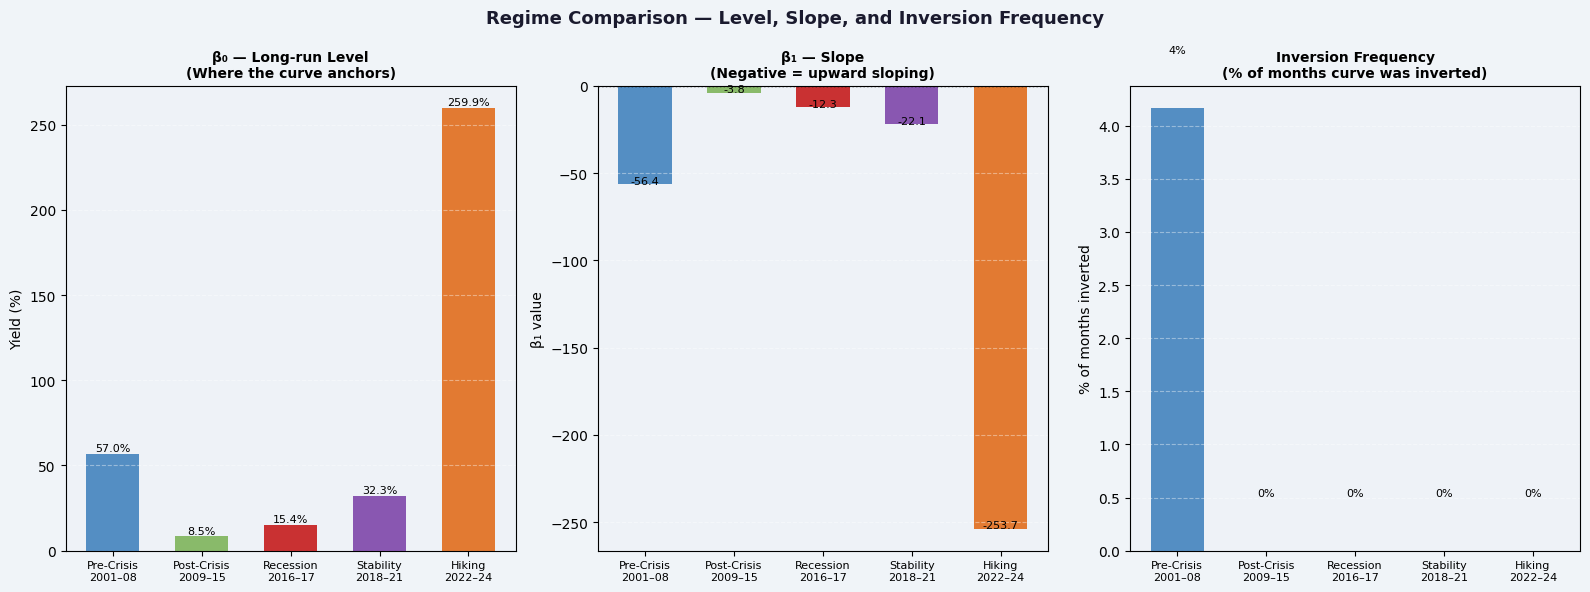

Chart saved as regime_comparison.png


In [45]:
# ── PLOT 2: Regime Comparison — Level, Slope, Inversion Frequency ─────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#f0f4f8')
fig.suptitle(
    'Regime Comparison — Level, Slope, and Inversion Frequency',
    fontsize=13, fontweight='bold', color='#1a1a2e'
)

# Data to plot — short regime names for x-axis labels
short_names = [
    'Pre-Crisis\n2001–08', 'Post-Crisis\n2009–15',
    'Recession\n2016–17',  'Stability\n2018–21',
    'Hiking\n2022–24'
]

# Pull data from regime_curves and ns_params
levels, slopes, inv_freqs = [], [], []

for (label, data), short in zip(regime_curves.items(), short_names):
    start, end = data['start'], data['end']

    # Level from NS β₀
    mask_ns = (ns_params.index >= start) & (ns_params.index <= end)
    sub_ns  = ns_params[mask_ns]
    levels.append(sub_ns['beta_0'].mean() if len(sub_ns) > 0 else np.nan)
    slopes.append(sub_ns['beta_1'].mean() if len(sub_ns) > 0 else np.nan)

    # Inversion frequency: % of months where 364D > 10Y or slope < 0
    mask_yc = (
        (yield_curve_clean.index >= start) &
        (yield_curve_clean.index <= end)
    )
    sub_yc = yield_curve_clean[mask_yc]
    if '364D' in sub_yc.columns and '91D' in sub_yc.columns:
        slope_series = sub_yc['364D'] - sub_yc['91D']
        valid = slope_series.dropna()
        inv_freq = (valid < 0).mean() * 100 if len(valid) > 0 else 0
    else:
        inv_freq = 0
    inv_freqs.append(inv_freq)

colors = [data['color'] for data in regime_curves.values()]
x      = np.arange(len(short_names))

# Panel 1: Level (β₀)
axes[0].set_facecolor('#eef2f7')
axes[0].grid(True, linestyle='--', alpha=0.4, color='white', axis='y')
bars = axes[0].bar(x, levels, color=colors, alpha=0.8, width=0.6)
axes[0].set_title('β₀ — Long-run Level\n(Where the curve anchors)',
                   fontsize=10, fontweight='bold')
axes[0].set_ylabel('Yield (%)')
axes[0].set_xticks(x); axes[0].set_xticklabels(short_names, fontsize=8)
for bar, val in zip(bars, levels):
    if not np.isnan(val):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# Panel 2: Slope (β₁)
axes[1].set_facecolor('#eef2f7')
axes[1].grid(True, linestyle='--', alpha=0.4, color='white', axis='y')
bars = axes[1].bar(x, slopes, color=colors, alpha=0.8, width=0.6)
axes[1].axhline(0, color='black', linewidth=1.0, linestyle=':')
axes[1].set_title('β₁ — Slope\n(Negative = upward sloping)',
                   fontsize=10, fontweight='bold')
axes[1].set_ylabel('β₁ value')
axes[1].set_xticks(x); axes[1].set_xticklabels(short_names, fontsize=8)
for bar, val in zip(bars, slopes):
    if not np.isnan(val):
        offset = 0.2 if val >= 0 else -0.8
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# Panel 3: Inversion frequency
axes[2].set_facecolor('#eef2f7')
axes[2].grid(True, linestyle='--', alpha=0.4, color='white', axis='y')
bars = axes[2].bar(x, inv_freqs, color=colors, alpha=0.8, width=0.6)
axes[2].set_title('Inversion Frequency\n(% of months curve was inverted)',
                   fontsize=10, fontweight='bold')
axes[2].set_ylabel('% of months inverted')
axes[2].set_xticks(x); axes[2].set_xticklabels(short_names, fontsize=8)
for bar, val in zip(bars, inv_freqs):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('regime_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#f0f4f8')
plt.show()
print("Chart saved as regime_comparison.png")

In [46]:
# ── REGIME INTERPRETATION TABLE ────────────────────────────────────────────

print("=" * 75)
print("REGIME ANALYSIS — INTERPRETATION SUMMARY")
print("=" * 75)

interpretations = {
    'Pre-Crisis (2001–2008)': (
        "High levels (~20%+) reflect post-liberalisation adjustment. "
        "Curve generally upward sloping as long-run inflation expectations "
        "were elevated but declining. CBN was building credibility."
    ),
    'Post-Crisis (2009–2015)': (
        "Oil windfall stabilised the naira. Yields compressed across all tenors. "
        "Curve slope steepened as short rates were cut but long rates held firm. "
        "This is the most 'normal' period in Nigerian fixed income history."
    ),
    'Oil Recession (2016–2017)': (
        "Naira devaluation + recession forced CBN to hike short rates aggressively. "
        "Curve flattened and at times inverted — short-end NTB rates exceeded "
        "long-end FGN bond yields. Highest inversion frequency in the dataset."
    ),
    'Stability (2018–2021)': (
        "CBN held rates steady while inflation moderated. "
        "Yield curve normalised — upward sloping again. "
        "COVID-19 caused brief yield compression in 2020 as CBN cut rates."
    ),
    'CBN Hiking Cycle (2022–2024)': (
        "Inflation hit 30%+ forcing CBN into an aggressive hiking cycle. "
        "Short-end yields surged above 20% again. Curve flattened. "
        "β₁ slope compressed toward zero — similar pattern to 2016."
    ),
}

for regime, text in interpretations.items():
    print(f"\n{'─'*75}")
    print(f"📍 {regime}")
    print(f"   {text}")

print(f"\n{'='*75}")
print("KEY TAKEAWAY: Nigerian yield curve regimes map closely to oil price cycles")
print("and CBN monetary policy responses — not just global interest rate trends.")

REGIME ANALYSIS — INTERPRETATION SUMMARY

───────────────────────────────────────────────────────────────────────────
📍 Pre-Crisis (2001–2008)
   High levels (~20%+) reflect post-liberalisation adjustment. Curve generally upward sloping as long-run inflation expectations were elevated but declining. CBN was building credibility.

───────────────────────────────────────────────────────────────────────────
📍 Post-Crisis (2009–2015)
   Oil windfall stabilised the naira. Yields compressed across all tenors. Curve slope steepened as short rates were cut but long rates held firm. This is the most 'normal' period in Nigerian fixed income history.

───────────────────────────────────────────────────────────────────────────
📍 Oil Recession (2016–2017)
   Naira devaluation + recession forced CBN to hike short rates aggressively. Curve flattened and at times inverted — short-end NTB rates exceeded long-end FGN bond yields. Highest inversion frequency in the dataset.

─────────────────────────────